<a href="https://colab.research.google.com/github/GutsAtGit/anomaly_detection_ema_gnn/blob/main/c10_m1_t0p5_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Dependecies

In [ ]:
import scipy.io as io
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from datetime import datetime
from google.colab import drive
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import roc_auc_score, roc_curve, auc, precision_recall_curve
import h5py
from contextlib import ExitStack
from torch.utils import data
import matplotlib.gridspec as gridspec
import joblib
import seaborn as sns
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
from torch import signal

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cpu


## Common functions and naming convention

### Signal Names and their colors

In [ ]:
six_signal_names = ["iA [A]", "iB [A]", "iC [A]", "omega [rad/s]",
                 "sin(theta)", "cos(theta)"]

five_signal_names = ["iA [A]", "iB [A]", "iC [A]", "omega [rad/s]",
                 "theta (rad)"]

color_names = {0: 'tab:blue', 1: 'tab:orange', 2: 'tab:green', 3: 'tab:red',
               4: 'tab:purple', 5: 'tab:brown', 6:'tab:black'} ## some extra colors

### EMA component name map

In [ ]:
component_name = {
    'motor': 'Component: Motor',
    'inverter': 'Component: Inverter'
}

### Model architecture type map

In [ ]:
model_name = {
    'fm': 'Full Model',
    'am': 'Ablation Model'
}

### Color Map

In [ ]:
color_map = {
    'fm': 'mako',
    'am': 'rocket'
}

### Fault type Map (test data type)

In [ ]:
fault_type = {
    'L0' : 'Inverter Normal Dataset',
    'L10' : 'Inveter Faulty with L=0.10',
    'L20' : 'Inverter Faulty with L=0.20',
    'L50' : 'Faulty with L=0.50',
    'L_all' : 'All Inverter Datasets',
    'motor' : 'Motor Test Data',
    'all' : 'All Test Data'
}

### Signal reconstruction function: Using Overlap-Add (OLA) method

In [ ]:
def signal_reconstruct(decoded, stride, total_length):
    """
    Reconstructs original signals from overlapping windows using NumPy.

    Args:
        decoded: Array of shape (B_window, N, W)
        stride: The step size used during windowing
        total_length: The original length of the signal (e.g., 500)

    Returns:
        final_reconstruction: Array of shape (num_samples, N, total_length)
    """
    B_window, N, W = decoded.shape

    # Copy the array so you don't accidentally modify your original data outside the function
    decoded_mod = decoded.copy()

    # Replace indices 0,1,2,3,4 with indices 5,6,7,8,9
    decoded_mod[:, :, :5] = decoded_mod[:, :, 5:10]
    decoded_mod[:, :, 250:255] = decoded_mod[:, :, 245:250]

    # Calculate number of windows per original sample
    K_per_sample = math.floor((total_length - W) / stride + 1)
    num_samples = B_window // K_per_sample

    # Reshape to separate the original samples: (num_samples, windows_per_sample, N, W)
    decoded_grouped = decoded_mod.reshape(num_samples, K_per_sample, N, W)

    # Initialize accumulation and count arrays
    reconstructed = np.zeros((num_samples, N, total_length))
    count = np.zeros((num_samples, N, total_length))

    for sample_idx in range(num_samples):
        for window_idx in range(K_per_sample):
            # Calculate positions
            start_pos = window_idx * stride
            end_pos = start_pos + W

            # Handle potential edge cases where window might exceed total_length
            actual_end = min(end_pos, total_length)
            slice_w = actual_end - start_pos

            # Accumulate values and counts for averaging overlaps
            reconstructed[sample_idx, :, start_pos:actual_end] += \
                decoded_grouped[sample_idx, window_idx, :, :slice_w]

            count[sample_idx, :, start_pos:actual_end] += 1

    # Average by the overlap count (using np.maximum to avoid division by zero)
    final_reconstruction = reconstructed / np.maximum(count, 1)

    return final_reconstruction

### Destandardization Function

In [ ]:
# De-standardization
def destandardize(signal_norm, scaler, N_norm=4):
    # signal_norm: (S, 6, T) -> [iA, iB, iC, omega, sin(theta_M), cos(theta_M)]
    signal_norm = signal_norm.detach().cpu()
    S, _, T = signal_norm.shape

    scaled_part = signal_norm[:, :N_norm, :]    # iA, iB, iC, omega
    untouched_part = signal_norm[:, N_norm:, :]  # sin, cos

    # (S, N, T) -> (S, T, N) -> (S*T, N)
    scaled_flat = scaled_part.permute(0, 2, 1).reshape(-1, N_norm)
    original_flat = scaler.inverse_transform(scaled_flat.numpy())

    # (S*T, N) -> (S, T, N) -> (S, N, T)
    original = torch.tensor(original_flat, dtype=torch.float32) \
                    .view(S, T, N_norm).permute(0, 2, 1)

    return torch.cat((original, untouched_part), dim=1)

### Inspection window preparation function

In [ ]:
def prepare_inspection_windows(arr, t_inspec):
    """
    Trims the last time step of an array of shape (s, n, t) and reshapes it
    into continuous inspection windows of shape (s, n, t // t_inspec, t_inspec).

    Parameters:
    -----------
    arr : numpy.ndarray
        Input array of shape (s, n, t)
    t_inspec : int
        The length of each inspection window (e.g., 100)

    Returns:
    --------
    numpy.ndarray
        Reshaped array of shape (s, n, num_windows, t_inspec)
    """
    if arr.ndim == 3:
        # Step 1: Drop the very last time step along the last axis (axis 2)
        # e.g., changing the time dimension from 20001 to 20000
        arr_trimmed = arr[:, :, :-1]

        s, n, t_trimmed = arr_trimmed.shape
        num_windows = t_trimmed // t_inspec

        # Step 2: Direct reshape
        # Because time is the last axis in a C-contiguous NumPy array,
        # this cleanly splits the timeline sequentially into consecutive windows.
        reshaped_arr = arr_trimmed.reshape(s, n, num_windows, t_inspec)
    else:
        arr_trimmed = arr[:, :-1]

        s, t_trimmed = arr_trimmed.shape
        num_windows = t_trimmed // t_inspec

        reshaped_arr = arr_trimmed.reshape(s, num_windows, t_inspec)

    return reshaped_arr

## Mount the Google Drive folder

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
%cd /content/gdrive/My\ Drive/MSc_Thesis/c10_m1_t0p5_full_model

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
/content/gdrive/My Drive/MSc_Thesis/c10_m1_t0p5_full_model


## See what's inside the folder

In [ ]:
print("Dataset folder contains: \n")
print(os.listdir("/content/gdrive/MyDrive/MSc_Thesis/c10_m1_t0p5_full_model")) # changes the folder accordingly

Dataset folder contains: 

['data', 'trained_model_state', 'data_inferencing_results', 'c10_m1_t0p5_full_n_ablation_model.ipynb', 'c10_m1_t0p5_full_n_ablation_inferencing.ipynb', 'c10_m1_t0p5_results.ipynb', 'hpc_trained_model_state']


## Load the data

### Load the raw test data

In [ ]:
# get into data folder
%cd /content/gdrive/MyDrive/MSc_Thesis/c10_m1_t0p5_full_model/data

motor_train_raw = np.load("motor_train.npy")
motor_val_raw = np.load("motor_val.npy")
motor_test_raw = np.load("motor_test.npy")


inv_L0_raw = np.load("inverter_normal.npy")
inv_L10_raw = np.load("inverter_fault_L10.npy")
inv_L20_raw = np.load("inverter_fault_L20.npy")
inv_L50_raw = np.load("inverter_fault_L50.npy")

# get back to main folder
!cd /content/gdrive/MyDrive/MSc_Thesis/c10_m1_t0p5_full_model/data

/content/gdrive/MyDrive/MSc_Thesis/c10_m1_t0p5_full_model/data


### Load the reconstructed test data

In [ ]:
# get into data folder
%cd /content/gdrive/MyDrive/MSc_Thesis/c10_m1_t0p5_full_model/data_inferencing_results/hpc_trained/

#--------------------------------------------Full Model---------------------------------------------------------------
# loading the dictionary
fm_inferencing_results_recon_signals = np.load("full_model_inferencing_results_reconstructed_signals.npz")

motor_train_fm_recon = fm_inferencing_results_recon_signals['motor_train_fm_recon_signal']
motor_val_fm_recon   = fm_inferencing_results_recon_signals['motor_val_fm_recon_signal']
motor_test_fm_recon  = fm_inferencing_results_recon_signals['motor_test_fm_recon_signal']

inv_L0_fm_recon  = fm_inferencing_results_recon_signals['inv_L0_fm_recon_signal']
inv_L10_fm_recon = fm_inferencing_results_recon_signals['inv_L10_fm_recon_signal']
inv_L20_fm_recon = fm_inferencing_results_recon_signals['inv_L20_fm_recon_signal']
inv_L50_fm_recon = fm_inferencing_results_recon_signals['inv_L50_fm_recon_signal']

#-------------------------------------------Ablation Model------------------------------------------------------------
# loading the dictionary
am_inferencing_results_recon_signals = np.load("ablation_model_inferencing_results_reconstructed_signals.npz")

motor_train_am_recon = am_inferencing_results_recon_signals['motor_train_am_recon_signal']
motor_val_am_recon = am_inferencing_results_recon_signals['motor_val_am_recon_signal']
motor_test_am_recon = am_inferencing_results_recon_signals['motor_test_am_recon_signal']

inv_L0_am_recon = am_inferencing_results_recon_signals['inv_L0_am_recon_signal']
inv_L10_am_recon = am_inferencing_results_recon_signals['inv_L10_am_recon_signal']
inv_L20_am_recon = am_inferencing_results_recon_signals['inv_L20_am_recon_signal']
inv_L50_am_recon = am_inferencing_results_recon_signals['inv_L50_am_recon_signal']

# get back to main folder
!cd /content/gdrive/MyDrive/MSc_Thesis/c10_m1_t0p5_full_model/data_inferencing_results

/content/gdrive/MyDrive/MSc_Thesis/c10_m1_t0p5_full_model/data_inferencing_results/hpc_trained


## Comparison plots

### Plotting function (raw vs recon)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def _to_numpy(x):
    if torch.is_tensor(x):
        x = x.detach().cpu().numpy()
    return np.asarray(x)


def plot_reconstruction(actual, recons, sample_idx=0, channels=None,
                        start=0, end=None, t=None, downsample=None,
                        color_by="channel", palette=None, title=None):
    """
    color_by: "channel" -> each channel gets its own color, series distinguished
                           by linestyle (solid, dashed, dotted, ...)
              "series"  -> each reconstruction gets its own color, same across
                           channels
    palette:  optional list of colors overriding the default cycle
    """
    actual = _to_numpy(actual)
    recons = {k: _to_numpy(v) for k, v in recons.items()}

    C, T = actual.shape[1], actual.shape[2]
    end = T if end is None else min(end, T)
    start = max(0, start)
    if start >= end:
        raise ValueError(f"start={start} must be less than end={end} (T={T})")

    channels = list(range(C)) if channels is None else channels
    t_full = np.arange(T) if t is None else np.asarray(t)

    n = end - start
    if downsample is None:
        downsample = max(1, n // 5000)
    sl = slice(start, end, downsample)
    t_plot = t_full[sl]

    if palette is None:
        palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    styles = ["-", "--", ":", "-."]

    fig, axes = plt.subplots(len(channels), 1, figsize=(15, 2.5 * len(channels)),
                             sharex=True)
    axes = np.atleast_1d(axes)

    for ax_i, (ax, c) in enumerate(zip(axes, channels)):
        ax.plot(t_plot, actual[sample_idx, c, sl], color="0.6", lw=1.0,
                label="Actual", zorder=1)

        for i, (label, rec) in enumerate(recons.items()):
            if color_by == "channel":
                color = palette[ax_i % len(palette)]
                ls = styles[i % len(styles)]
            else:
                color = palette[i % len(palette)]
                ls = "-"
            ax.plot(t_plot, rec[sample_idx, c, sl], color=color, ls=ls,
                    lw=1.0, label=label, zorder=2 + i)

        name = six_signal_names[c] if c < len(six_signal_names) else f"ch {c}"
        ax.set_ylabel(name)
        ax.grid(alpha=0.3)
        ax.legend(loc="upper right", ncol=1 + len(recons), fontsize=8)

    axes[-1].set_xlabel("Timestep" if t is None else "Time")

    header = f"steps {start}–{end}" + (f" (every {downsample})" if downsample > 1 else "")
    fig.suptitle(f"{title} — {header}" if title else header, y=0.995)
    fig.tight_layout()
    return fig, axes

### plots

(<Figure size 1500x1500 with 6 Axes>,
 array([<Axes: ylabel='iA [A]'>, <Axes: ylabel='iB [A]'>,
        <Axes: ylabel='iC [A]'>, <Axes: ylabel='omega [rad/s]'>,
        <Axes: ylabel='sin(theta)'>,
        <Axes: xlabel='Timestep', ylabel='cos(theta)'>], dtype=object))

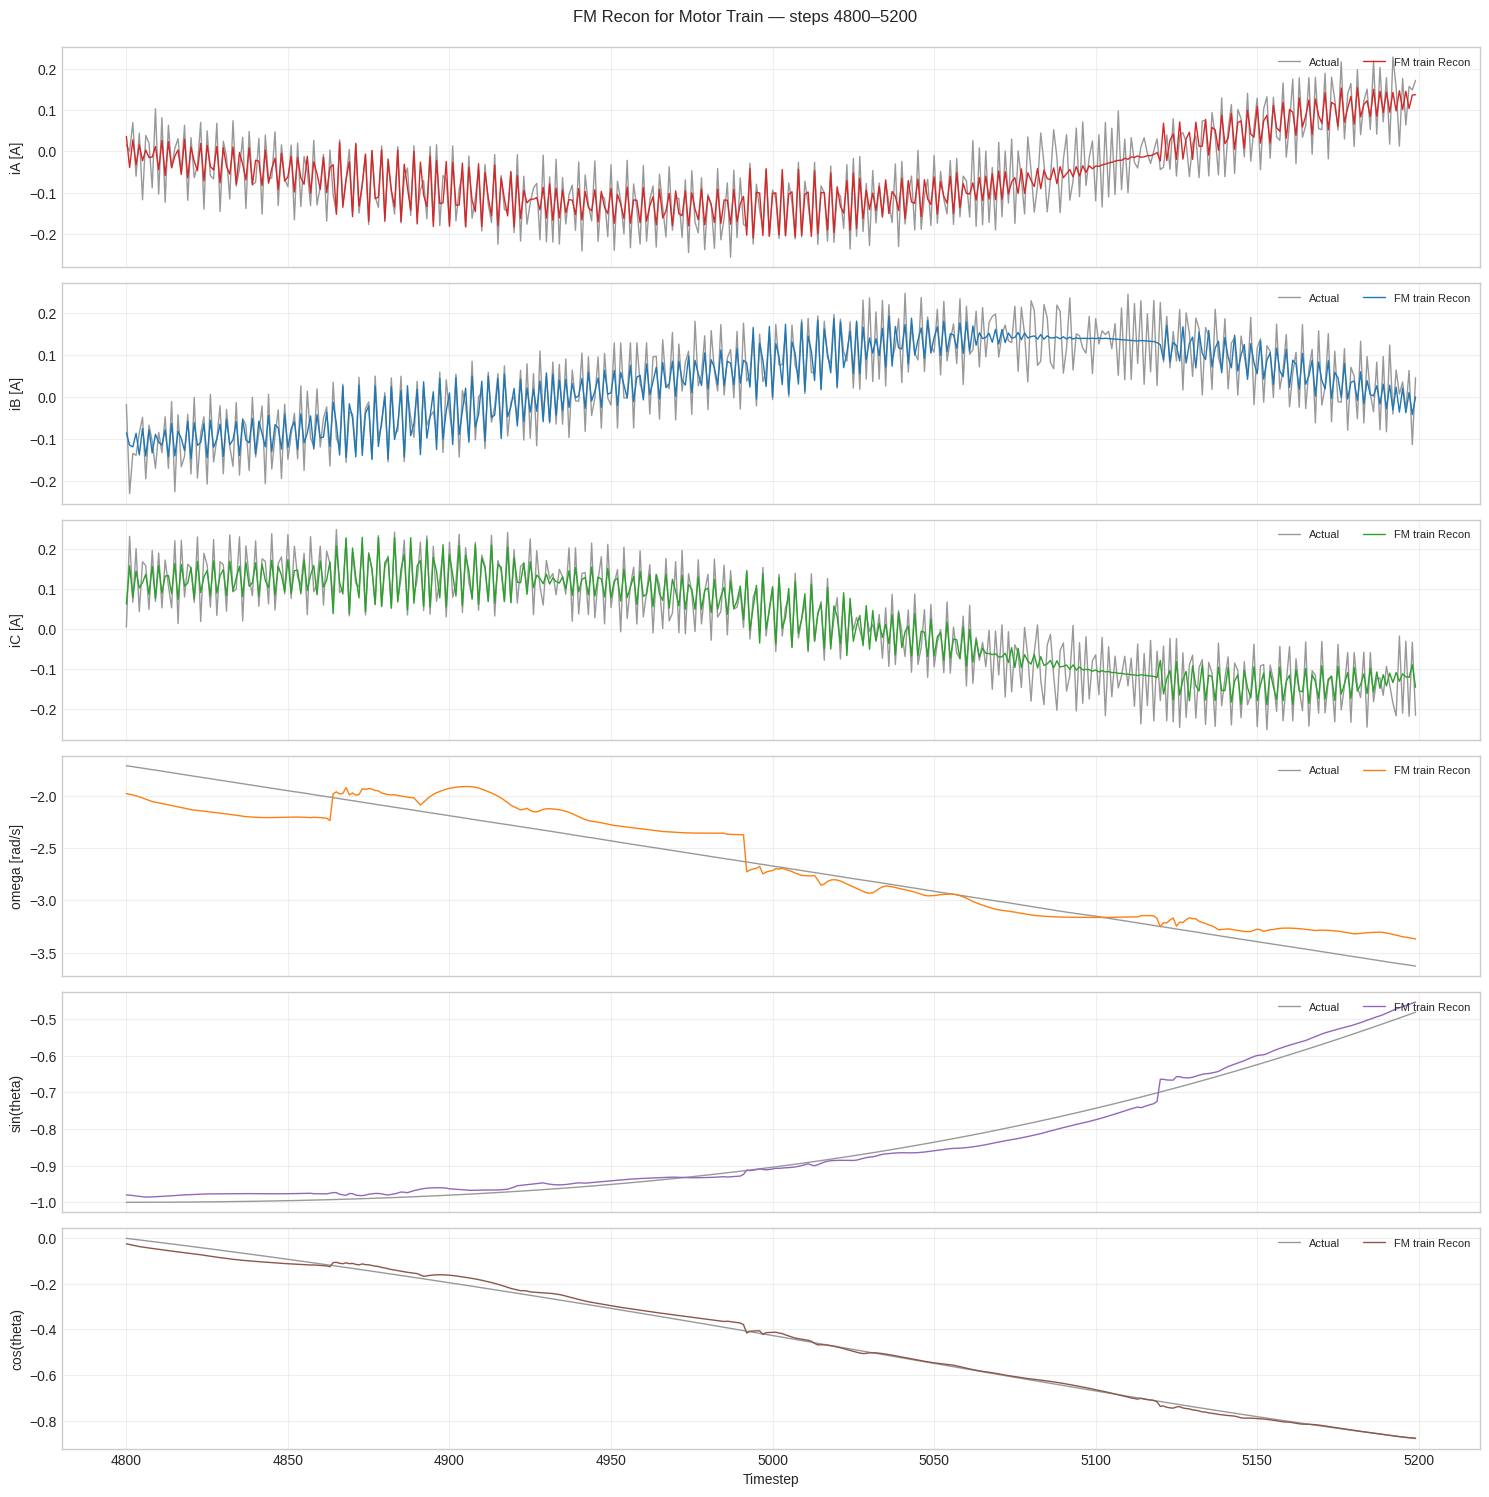

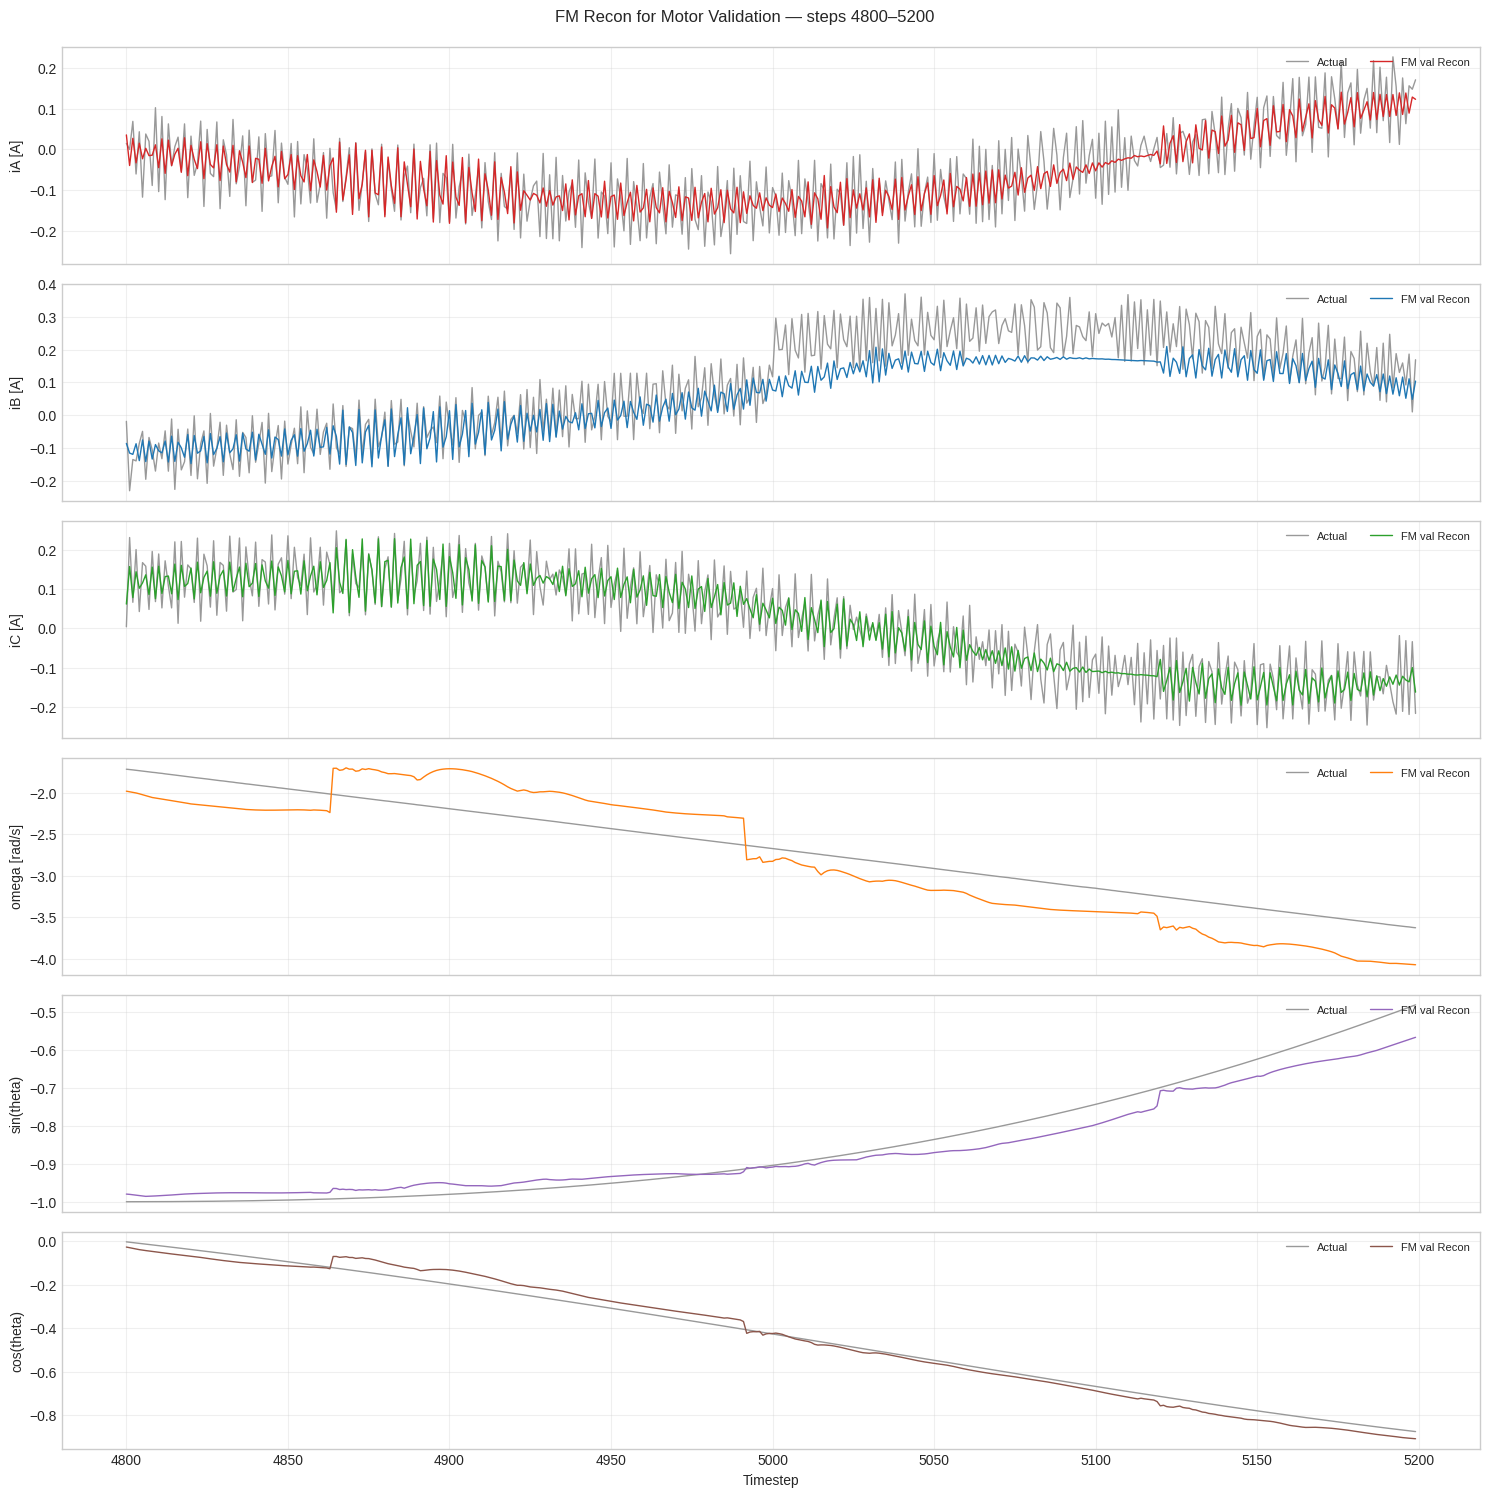

In [ ]:
## USAGE
# # Each channel in its own color (default)
# plot_reconstruction(motor_val_signal, {"Recon": motor_val_recon_signal},
#                     start=20000, end=20400)

# # Train vs val recon on the same axes — colors separate the two series
# plot_reconstruction(motor_val_signal,
#                     {"Train recon": motor_train_recon_signal,
#                      "Val recon": motor_val_recon_signal},
#                     color_by="series", start=20000, end=20400)

# # Custom palette
# plot_reconstruction(motor_val_signal, {"Recon": motor_val_recon_signal},
#                     palette=["#d62728", "#1f77b4", "#2ca02c",
#                              "#ff7f0e", "#9467bd", "#8c564b"])


# plot_reconstruction(motor_test_raw, {"FM Reconstructed": motor_test_fm_recon},
#                     sample_idx=3, title="Training — motor")

# plot_reconstruction(motor_val_raw, {"FM Reconstructed": motor_val_fm_recon},
#                     sample_idx=0, title="Validation — motor")

# plot_reconstruction(motor_train_raw, {"AM Reconstructed": motor_train_am_recon},
#                     sample_idx=0, title="Training — motor")

# plot_reconstruction(motor_val_raw, {"AM Reconstructed": motor_val_am_recon},
#                     sample_idx=0, title="Validation — motor")

plot_reconstruction(inv_L0_raw, {"FM train Recon": inv_L0_fm_recon},sample_idx=3,
                    palette=["#d62728", "#1f77b4", "#2ca02c",
                             "#ff7f0e", "#9467bd", "#8c564b"], start=4800, end=5200, title='FM Recon for Motor Train')

plot_reconstruction(inv_L20_raw, {"FM val Recon": inv_L20_fm_recon}, sample_idx=3,
                    palette=["#d62728", "#1f77b4", "#2ca02c",
                             "#ff7f0e", "#9467bd", "#8c564b"], start=4800, end=5200, title='FM Recon for Motor Validation')

### full vs ablation (function)

In [ ]:
def plot_full_vs_ablation(actual, recon_fm, recon_am, sample_idx=0, channels=None,
                          start=0, end=None, t=None, downsample=None, title=None,
                          mask_tail=True):
    """
    actual   : (S, C, T) raw signals
    recon_fm : (S, C, T) full-model reconstruction (same units as actual)
    recon_am : (S, C, T) ablation-model reconstruction
    mask_tail: hide the last samples that no 256-long window covers (OLA leaves
               them empty), so the reconstruction does not drop to 0 at the end
    """
    actual = _to_numpy(actual)
    recon_fm = _to_numpy(recon_fm).astype(float)
    recon_am = _to_numpy(recon_am).astype(float)

    C, T = actual.shape[1], actual.shape[2]
    end = T if end is None else min(end, T)
    start = max(0, start)
    if start >= end:
        raise ValueError(f"start={start} must be less than end={end} (T={T})")

    if mask_tail:
        covered = ((T - 256) // 128) * 128 + 256
        recon_fm[:, :, covered:] = np.nan
        recon_am[:, :, covered:] = np.nan

    channels = list(range(C)) if channels is None else channels
    t_full = np.arange(T) if t is None else np.asarray(t)

    n = end - start
    if downsample is None:
        downsample = max(1, n // 5000)
    sl = slice(start, end, downsample)
    t_plot = t_full[sl]

    fig, axes = plt.subplots(len(channels), 1, figsize=(15, 2.5 * len(channels)),
                             sharex=True)
    axes = np.atleast_1d(axes)

    for ax, c in zip(axes, channels):
        a = actual[sample_idx, c, sl]
        fm = recon_fm[sample_idx, c, sl]
        am = recon_am[sample_idx, c, sl]
        mae_fm = np.nanmean(np.abs(fm - a))
        mae_am = np.nanmean(np.abs(am - a))

        ax.plot(t_plot, a, color="0.6", lw=1.0, label="Raw", zorder=1)
        ax.plot(t_plot, fm, color="#1f77b4", ls="-", lw=0.8,
                label=f"Full model (MAE {mae_fm:.3g})", zorder=3)
        ax.plot(t_plot, am, color="#d62728", ls="-", lw=0.8,
                label=f"Ablation model (MAE {mae_am:.3g})", zorder=2)

        name = six_signal_names[c] if c < len(six_signal_names) else f"ch {c}"
        ax.set_ylabel(name)
        ax.grid(alpha=0.3)
        ax.legend(loc="upper right", ncol=3, fontsize=8)

        axes[-1].set_xlabel("Timestep" if t is None else "Time [s]")

    header = (f"sample {sample_idx}, t = {t_full[start]:.3f}–{t_full[end - 1]:.3f} s"
              if t is not None else f"sample {sample_idx}, steps {start}–{end}")
    fig.suptitle(f"{title} — {header}" if title else header, y=0.995)
    fig.tight_layout()
    return fig, axes

(<Figure size 1500x1500 with 6 Axes>,
 array([<Axes: ylabel='iA [A]'>, <Axes: ylabel='iB [A]'>,
        <Axes: ylabel='iC [A]'>, <Axes: ylabel='omega [rad/s]'>,
        <Axes: ylabel='sin(theta)'>,
        <Axes: xlabel='Timestep', ylabel='cos(theta)'>], dtype=object))

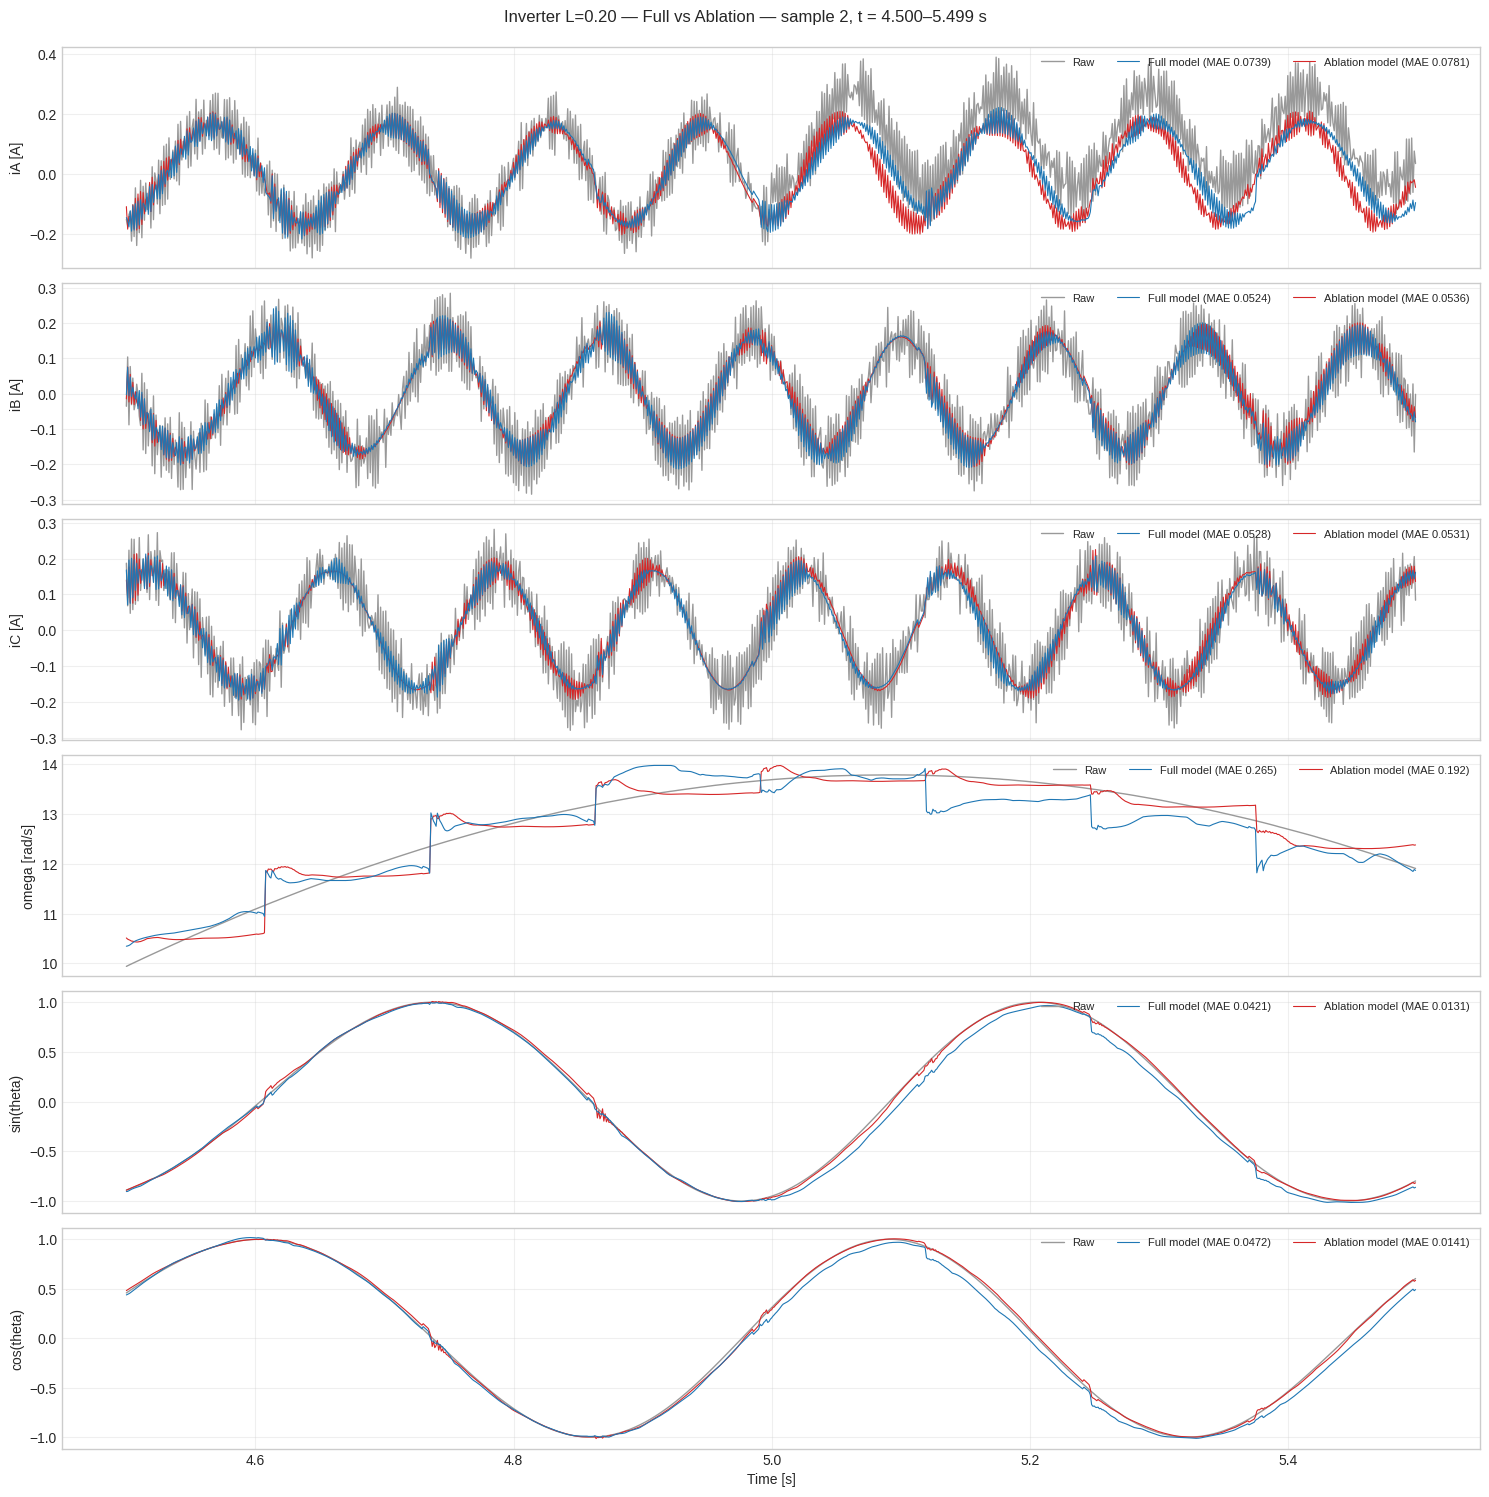

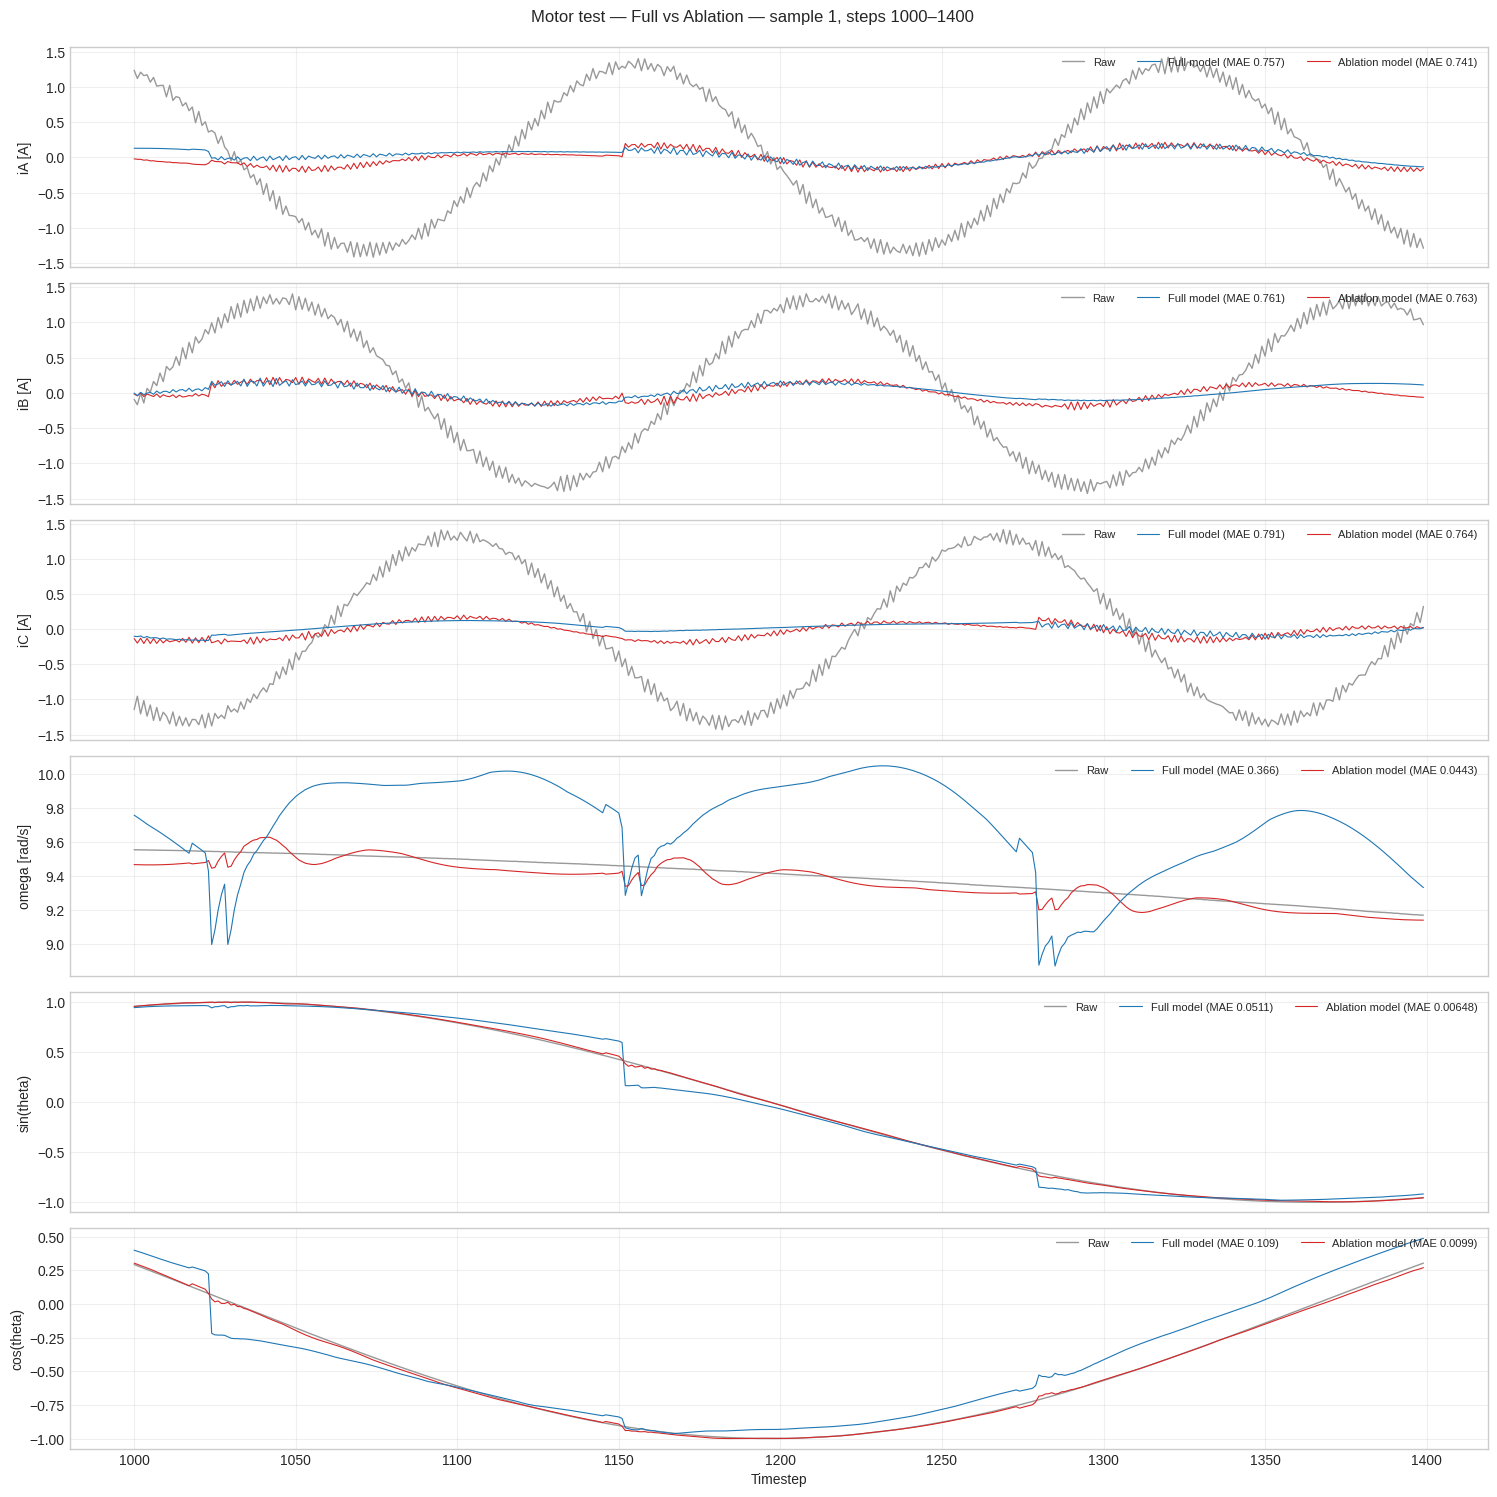

In [ ]:
# inverter L20, around the fault onset at t = 5 s (sample 5000)
T = inv_L20_raw.shape[-1]
plot_full_vs_ablation(inv_L20_raw, inv_L20_fm_recon, inv_L20_am_recon,
                      sample_idx=2, start=4500, end=5500,
                      t=np.arange(T) / 1000,          # 1 kHz -> seconds
                      title="Inverter L=0.20 — Full vs Ablation")

# motor test, a faulty sample (every 4th sample is healthy: 0, 4, 8, ...)
plot_full_vs_ablation(motor_test_raw, motor_test_fm_recon, motor_test_am_recon,
                      sample_idx=1, start=1000, end=1400,
                      title="Motor test — Full vs Ablation")

## Calculating residuls using Signals
- $res = \hat{Y} - Y$ for others

- $res_{\theta}(t) = \mathrm{atan2}(\frac{\hat{s}(t)c(t) - \hat{c}(t)s(t)}{\hat{c}(t)c(t) - \hat{s}(t)s(t)})$ for $\theta$

In [ ]:
SIN, COS = 4, 5
CUR_VEL = [0, 1, 2, 3]

def angle_residual(actual, recon):
    s,  c  = actual[:, SIN, :], actual[:, COS, :]
    sh, ch = recon[:,  SIN, :], recon[:,  COS, :]
    return np.arctan2(c*sh - s*ch, s*sh + c*ch)          # = theta_hat - theta

# def residuals(actual, recon):
#     """Returns (S, 5, T): [iA, iB, iC, omega, d_theta], all recon - actual."""
#     res = recon[:, CUR_VEL, :] - actual[:, CUR_VEL, :]
#     return np.concatenate([res, angle_residual(actual, recon)[:, None, :]], axis=1)

def residuals(actual, recon):
    """Returns (S, 5, T): [iA, iB, iC, omega, d_theta], all recon - actual."""
    res = recon[:, CUR_VEL, :] - actual[:, CUR_VEL, :]
    out = np.concatenate([res, angle_residual(actual, recon)[:, None, :]], axis=1)
    T = actual.shape[-1]
    out[:, :, ((T - 256) // 128) * 128 + 256:] = 0.0   # tail no 256-window covers
    return out

#--------------------------------------------Full Model---------------------------------------------------------------

# Motor
motor_train_fm_res = residuals(motor_train_raw, motor_train_fm_recon)
motor_val_fm_res   = residuals(motor_val_raw,   motor_val_fm_recon)
motor_test_fm_res  = residuals(motor_test_raw,  motor_test_fm_recon)

# Inverter
inv_L0_fm_res  = residuals(inv_L0_raw,  inv_L0_fm_recon)
inv_L10_fm_res = residuals(inv_L10_raw, inv_L10_fm_recon)
inv_L20_fm_res = residuals(inv_L20_raw, inv_L20_fm_recon)
inv_L50_fm_res = residuals(inv_L50_raw, inv_L50_fm_recon)

#-------------------------------------------Ablation Model------------------------------------------------------------

# Motor
motor_train_am_res = residuals(motor_train_raw, motor_train_am_recon)
motor_val_am_res   = residuals(motor_val_raw, motor_val_am_recon)
motor_test_am_res  = residuals(motor_test_raw, motor_test_am_recon)

# Inverter
inv_L0_am_res  = residuals(inv_L0_raw, inv_L0_am_recon)
inv_L10_am_res = residuals(inv_L10_raw, inv_L10_am_recon)
inv_L20_am_res = residuals(inv_L20_raw, inv_L20_am_recon)
inv_L50_am_res = residuals(inv_L50_raw, inv_L50_am_recon)

## $\mu_{res}^{val}$[5] and $\sigma_{res}^{val}$[5] (Full and Ablation Models)

In [ ]:
#--------------------------------------------------Full Model------------------------------------------------
motor_val_fm_res_flat = motor_val_fm_res.transpose(0, 2, 1).reshape(-1, 5)   # (samples*T, 5)
z_score_scaler_val_fm_res = StandardScaler().fit(motor_val_fm_res_flat)

#----------------------------------------------------Ablation Model------------------------------------------
motor_val_am_res_flat = motor_val_am_res.transpose(0, 2, 1).reshape(-1, 5)
z_score_scaler_val_am_res = StandardScaler().fit(motor_val_am_res_flat)

### Saving and loading $\mu_{res}^{val}$ and $\sigma_{res}^{val}$

In [ ]:
# get into data folder
%cd /content/gdrive/MyDrive/MSc_Thesis/c10_m1_t0p5_full_model/data/hpc_scaler

# joblib.dump(z_score_scaler_val_fm_res, 'z_score_scaler_val_fm_res.joblib')
# joblib.dump(z_score_scaler_val_am_res, 'z_score_scaler_val_am_res.joblib')

z_score_scaler_val_fm_res = joblib.load('z_score_scaler_val_fm_res.joblib')
z_score_scaler_val_am_res = joblib.load('z_score_scaler_val_am_res.joblib')

# get back to main folder
!cd /content/gdrive/MyDrive/MSc_Thesis/c10_m1_t0p5_full_model/data

/content/gdrive/MyDrive/MSc_Thesis/c10_m1_t0p5_full_model/data/hpc_scaler


## Calculate Z-scores for Motor validation and test and all Inverter.

### $Z$-score function


In [ ]:
def z_score(res, scaler):
    """res: (samples, 5, T). Applies a StandardScaler fitted on (N, 5)."""
    s, n, t = res.shape
    flat = res.transpose(0, 2, 1).reshape(-1, n)      # (samples*T, 5)
    return scaler.transform(flat).reshape(s, t, n).transpose(0, 2, 1)

### $Z$-scores

In [ ]:
#--------------------------------------------------Full Model------------------------------------------------
# Motor
z_motor_train_fm  = z_score(motor_train_fm_res,  z_score_scaler_val_fm_res)
z_motor_val_fm    = z_score(motor_val_fm_res,    z_score_scaler_val_fm_res)
z_motor_test_fm   = z_score(motor_test_fm_res,   z_score_scaler_val_fm_res)

# Inverter
z_inv_L0_fm  = z_score(inv_L0_fm_res,  z_score_scaler_val_fm_res)
z_inv_L10_fm = z_score(inv_L10_fm_res, z_score_scaler_val_fm_res)
z_inv_L20_fm = z_score(inv_L20_fm_res, z_score_scaler_val_fm_res)
z_inv_L50_fm = z_score(inv_L50_fm_res, z_score_scaler_val_fm_res)

print(z_motor_val_fm.mean(axis=(0, 2)))   # ~0 for all five
print(z_motor_val_fm.std(axis=(0, 2)))    # ~1 for all five

#----------------------------------------------------Ablation Model------------------------------------------
# Motor
z_motor_train_am  = z_score(motor_train_am_res,  z_score_scaler_val_am_res)
z_motor_val_am    = z_score(motor_val_am_res,    z_score_scaler_val_am_res)
z_motor_test_am   = z_score(motor_test_am_res,   z_score_scaler_val_am_res)

# Inverter
z_inv_L0_am  = z_score(inv_L0_am_res,  z_score_scaler_val_am_res)
z_inv_L10_am = z_score(inv_L10_am_res, z_score_scaler_val_am_res)
z_inv_L20_am = z_score(inv_L20_am_res, z_score_scaler_val_am_res)
z_inv_L50_am = z_score(inv_L50_am_res, z_score_scaler_val_am_res)

[-1.19259480e-17  2.16246624e-17 -2.87449780e-17  3.60292618e-17
  1.73587584e-17]
[1. 1. 1. 1. 1.]


### Splitting all data z-scores into the inspection windows

In [ ]:
t_inspec = 100 # shape: [s, n, num_windows, window_length]

#--------------------------------------------Full Model---------------------------------------------------------------

# Motor
z_motor_train_fm_iw = prepare_inspection_windows(z_motor_train_fm, t_inspec)
z_motor_val_fm_iw   = prepare_inspection_windows(z_motor_val_fm, t_inspec)
z_motor_test_fm_iw  = prepare_inspection_windows(z_motor_test_fm, t_inspec)

# Inverter
z_inv_L0_fm_iw  = prepare_inspection_windows(z_inv_L0_fm, t_inspec)
z_inv_L10_fm_iw = prepare_inspection_windows(z_inv_L10_fm, t_inspec)
z_inv_L20_fm_iw = prepare_inspection_windows(z_inv_L20_fm, t_inspec)
z_inv_L50_fm_iw = prepare_inspection_windows(z_inv_L50_fm, t_inspec)

#-------------------------------------------Ablation Model------------------------------------------------------------

# Motor
z_motor_train_am_iw = prepare_inspection_windows(z_motor_train_am, t_inspec)
z_motor_val_am_iw   = prepare_inspection_windows(z_motor_val_am, t_inspec)
z_motor_test_am_iw  = prepare_inspection_windows(z_motor_test_am, t_inspec)

# Inverter
z_inv_L0_am_iw  = prepare_inspection_windows(z_inv_L0_am, t_inspec)
z_inv_L10_am_iw = prepare_inspection_windows(z_inv_L10_am, t_inspec)
z_inv_L20_am_iw = prepare_inspection_windows(z_inv_L20_am, t_inspec)
z_inv_L50_am_iw = prepare_inspection_windows(z_inv_L50_am, t_inspec)

## Calculating anomaly scores ($A_{score}$) from $Z_{score}$ by taking Mean Absolute Error (MAE)


### Window anomaly scores ($A_{window}$ [S, 5, num_windows])

In [ ]:
#--------------------------------------------Full Model---------------------------------------------------------------
# Motor
a_win_score_motor_train_fm = np.mean(np.abs(z_motor_train_fm_iw), axis=3)
a_win_score_motor_val_fm   = np.mean(np.abs(z_motor_val_fm_iw), axis=3)
a_win_score_motor_test_fm  = np.mean(np.abs(z_motor_test_fm_iw), axis=3)

# Inverter
a_win_score_inv_L0_fm  = np.mean(np.abs(z_inv_L0_fm_iw), axis=3)
a_win_score_inv_L10_fm = np.mean(np.abs(z_inv_L10_fm_iw), axis=3)
a_win_score_inv_L20_fm = np.mean(np.abs(z_inv_L20_fm_iw), axis=3)
a_win_score_inv_L50_fm = np.mean(np.abs(z_inv_L50_fm_iw), axis=3)

#-------------------------------------------Ablation Model------------------------------------------------------------
# Motor
a_win_score_motor_train_am = np.mean(np.abs(z_motor_train_am_iw), axis=3)
a_win_score_motor_val_am   = np.mean(np.abs(z_motor_val_am_iw), axis=3)
a_win_score_motor_test_am  = np.mean(np.abs(z_motor_test_am_iw), axis=3)

# Inverter
a_win_score_inv_L0_am  = np.mean(np.abs(z_inv_L0_am_iw), axis=3)
a_win_score_inv_L10_am = np.mean(np.abs(z_inv_L10_am_iw), axis=3)
a_win_score_inv_L20_am = np.mean(np.abs(z_inv_L20_am_iw), axis=3)
a_win_score_inv_L50_am = np.mean(np.abs(z_inv_L50_am_iw), axis=3)

### Aggregating $A_{window}$ across signals by taking maximum value
- $A_{max} = max(A_{score}, dim = 1)$

In [ ]:
#--------------------------------------------Full Model---------------------------------------------------------------
# Motor
a_win_max_motor_train_fm = np.max(a_win_score_motor_train_fm, axis=1)
a_win_max_motor_val_fm   = np.max(a_win_score_motor_val_fm, axis=1)
a_win_max_motor_test_fm  = np.max(a_win_score_motor_test_fm, axis=1)

# Inverter
a_win_max_inv_L0_fm = np.max(a_win_score_inv_L0_fm, axis=1)
a_win_max_inv_L10_fm   = np.max(a_win_score_inv_L10_fm, axis=1)
a_win_max_inv_L20_fm  = np.max(a_win_score_inv_L20_fm, axis=1)
a_win_max_inv_L50_fm  = np.max(a_win_score_inv_L50_fm, axis=1)

#-------------------------------------------Ablation Model------------------------------------------------------------
# Motor
a_win_max_motor_train_am = np.max(a_win_score_motor_train_am, axis=1)
a_win_max_motor_val_am   = np.max(a_win_score_motor_val_am, axis=1)
a_win_max_motor_test_am  = np.max(a_win_score_motor_test_am, axis=1)

# Inverter
a_win_max_inv_L0_am  = np.max(a_win_score_inv_L0_am, axis=1)
a_win_max_inv_L10_am = np.max(a_win_score_inv_L10_am, axis=1)
a_win_max_inv_L20_am = np.max(a_win_score_inv_L20_am, axis=1)
a_win_max_inv_L50_am = np.max(a_win_score_inv_L50_am, axis=1)

## Calculate scalers for threshold calculation
- $\mu_{A, score}^{val}$ and $\sigma_{A, score}^{val}$ $←$ For specific window and signals
- $\mu_{A, max}^{val}$ and $\sigma_{A, max}^{val}$ $←$ For specific window

#### For $\mu_{A, score}^{val}$ [5] and $\sigma_{A, score}^{val}$ [5] (not saving since any score is not saved)

In [ ]:
#--------------------------------------------------Full Model------------------------------------------------
a_win_score_motor_val_fm_flat = a_win_score_motor_val_fm.transpose(0, 2, 1).reshape(-1, 5)   # (samples*T, 5)
a_win_score_Sscaler_val_fm    = StandardScaler().fit(a_win_score_motor_val_fm_flat)
#a_win_score_Rscaler_val_fm    = RobustScaler().fit(a_win_score_motor_val_fm_flat)

#----------------------------------------------------Ablation Model------------------------------------------
a_win_score_motor_val_am_flat = a_win_score_motor_val_am.transpose(0, 2, 1).reshape(-1, 5)   # (samples*T, 5)
a_win_score_Sscaler_val_am    = StandardScaler().fit(a_win_score_motor_val_am_flat)
#a_win_score_Rscaler_val_am    = RobustScaler().fit(a_win_score_motor_val_am_flat)

#### For $\mu_{A, max}^{val}$ and $\sigma_{A, max}^{val}$ (not saving since any score is not saved)

In [ ]:
#--------------------------------------------------Full Model------------------------------------------------
a_win_max_motor_val_fm_flat = a_win_max_motor_val_fm.reshape(-1, 1)   # (samples*T, 1) for a single feature
a_win_max_Sscaler_val_fm    = StandardScaler().fit(a_win_max_motor_val_fm_flat)
#a_win_max_Rscaler_val_fm    = RobustScaler().fit(a_win_max_motor_val_fm_flat)

#----------------------------------------------------Ablation Model------------------------------------------
a_win_max_motor_val_am_flat = a_win_max_motor_val_am.reshape(-1, 1)   # (samples*T, 1) for a single feature
a_win_max_Sscaler_val_am    = StandardScaler().fit(a_win_max_motor_val_am_flat)
#a_win_max_Rscaler_val_am    = RobustScaler().fit(a_win_max_motor_val_am_flat)

### Calculate threshold: $thr = \mu + C*\sigma$ with $C = \{1, 2, 3, 4\}$

In [ ]:
C = [1, 2, 3, 4]

#--------------------------------------------------Full Model------------------------------------------------

thr_a_score = a_win_score_Sscaler_val_fm.mean_ + 3 * a_win_score_Sscaler_val_fm.scale_ # [5]
thr_a_max   = a_win_max_Sscaler_val_fm.mean_   + 3 * a_win_max_Sscaler_val_fm.scale_   # [1]

#-------------------------------------------------Ablation Model----------------------------------------------

thr_a_score_am = a_win_score_Sscaler_val_am.mean_ + 3 * a_win_score_Sscaler_val_am.scale_ # [5]
thr_a_max_am   = a_win_max_Sscaler_val_am.mean_   + 3 * a_win_max_Sscaler_val_am.scale_   # [1]

## Define truth matrices:
- For the signal specific scores $[S, 5, N_{win}]$:

```
tm_motor_test_score = [1, 80, 5, 50] where [0, 0::4, :, :] = False for healthy samples
tm_inv_all_score = [4, 30, 5, 200] where [0, :, :, :] = False for normal dataset; and [1:, :, :, 0:50] = False for t<5 being normal
```
- For the max aggregated scores $[S, N_{window}]$:

```
tm_motor_test_max = [1, 80, 50] where [0, 0::4, :] = False for healthy samples
tm_inv_all_max = [4, 30, 200] where [0, :, :] = False for normal dataset; and [1:, :, 0:50] = False for t<5 being normal
```

- For motor validation set as well:
```
tm_motor_val_score = [1, 13, 5, 500] where [:, :, :, :] = False since everything is healthy
tm_motor_val_max = [1, 13, 500] where [:, :, :] = False
```



### signals = 5

In [ ]:
tm_motor_test_score = np.ones([1, 80, 5, 50], dtype=bool)
tm_motor_test_score[:, 0::4, :, :] = False

tm_motor_val_score = np.ones([1, 13, 5, 500], dtype=bool)
tm_motor_val_score[:, :, :, :] = False

tm_inv_all_score = np.ones([4, 30, 5, 200], dtype=bool)
tm_inv_all_score[0, :, :, :] = False
tm_inv_all_score[1:, :, :, 0:50] = False

### max aggregated

In [ ]:
tm_motor_test_max = np.ones([1, 80, 50], dtype=bool)
tm_motor_test_max[:, 0::4, :] = False

tm_motor_val_max = np.ones([1, 13, 500], dtype=bool)
tm_motor_val_max[:, :, :] = False

tm_inv_all_max = np.ones([4, 30, 200], dtype=bool)
tm_inv_all_max[0, :, :] = False
tm_inv_all_max[1:, :, 0:50] = False

## Stack the anomaly scores

### signals = 5

In [ ]:
#----------------------------------------------------Full Model-----------------------------------------------
# Motor
a_win_score_motor_val_fm_stack = np.stack([a_win_score_motor_val_fm], axis=0)
a_win_score_motor_test_fm_stack = np.stack([a_win_score_motor_test_fm], axis=0)

# Inverter
a_win_score_inv_all_fm_stack = np.stack([a_win_score_inv_L0_fm,
                                     a_win_score_inv_L10_fm,
                                     a_win_score_inv_L20_fm,
                                     a_win_score_inv_L50_fm], axis=0)

#-----------------------------------------------Ablation Model-------------------------------------------------
# Motor
a_win_score_motor_val_am_stack = np.stack([a_win_score_motor_val_am], axis=0)
a_win_score_motor_test_am_stack = np.stack([a_win_score_motor_test_am], axis=0)

# Inverter
a_win_score_inv_all_am_stack = np.stack([a_win_score_inv_L0_am,
                                     a_win_score_inv_L10_am,
                                     a_win_score_inv_L20_am,
                                     a_win_score_inv_L50_am], axis=0)

### max aggregated

In [ ]:
#----------------------------------------------------Full Model-----------------------------------------------
# Motor
a_win_max_motor_val_fm_stack = np.stack([a_win_max_motor_val_fm], axis=0)
a_win_max_motor_test_fm_stack = np.stack([a_win_max_motor_test_fm], axis=0)

# Inverter
a_win_max_inv_all_fm_stack = np.stack([a_win_max_inv_L0_fm,
                                     a_win_max_inv_L10_fm,
                                     a_win_max_inv_L20_fm,
                                     a_win_max_inv_L50_fm], axis=0)

#-----------------------------------------------Ablation Model-------------------------------------------------
# Motor
a_win_max_motor_val_am_stack = np.stack([a_win_max_motor_val_am], axis=0)
a_win_max_motor_test_am_stack = np.stack([a_win_max_motor_test_am], axis=0)

# Inverter
a_win_max_inv_all_am_stack = np.stack([a_win_max_inv_L0_am,
                                       a_win_max_inv_L10_am,
                                       a_win_max_inv_L20_am,
                                       a_win_max_inv_L50_am], axis=0)

## AUROC Plots

plotting function

In [ ]:
def plot_AUROC_A_model(y_true,
                      score_gnn,
                      score_ablation):

  # for GNN
  fpr_gnn, tpr_gnn, thresholds_gnn = roc_curve(y_true, score_gnn)
  roc_auc_gnn = auc(fpr_gnn, tpr_gnn)

  # for Ablation
  fpr_ablation, tpr_ablation, thresholds_ablation = roc_curve(y_true, score_ablation)
  roc_auc_ablation = auc(fpr_ablation, tpr_ablation)

  # Set a professional style
  plt.style.use('seaborn-v0_8-whitegrid') # or 'ggplot'
  plt.figure(figsize=(9, 8))

  # --- GNN Plotting (Solid Line) ---
  plt.plot(fpr_gnn, tpr_gnn,
           color='#1f77b4', # Professional Blue
           linestyle='-',  # Solid line
           linewidth=3,
           alpha=1.0,
           label=f"{model_name['fm']} (AUC = {roc_auc_gnn:.3f})")

  # --- Ablation Plotting (Dashed Line) ---
  plt.plot(fpr_ablation, tpr_ablation,
           color='#d62728', # Professional Red
           linestyle='--', # Dashed line
           linewidth=2.5,
           alpha=0.8,
           label=f"{model_name['am']} (AUC = {roc_auc_ablation:.3f})")

  # --- Baseline ---
  plt.plot([0, 1], [0, 1], color='#444444', lw=1.5, linestyle=':', alpha=0.6, label='Random Classifier')

  # --- Aesthetic Polishing ---
  plt.xlabel('False Positive Rate (FPR)', fontsize=13, fontweight='bold', labelpad=12)
  plt.ylabel('True Positive Rate (TPR)', fontsize=13, fontweight='bold', labelpad=12)

  plt.title('Performance Comparison: GNN vs. Ablation Model\nArea Under ROC based on $A_{max}$',
            fontsize=15, fontweight='bold', pad=20)

  plt.xlim([-0.02, 1.02])
  plt.ylim([0.0, 1.05])
  plt.xticks(np.arange(0, 1.1, 0.1))
  plt.yticks(np.arange(0, 1.1, 0.1))

  # Modern legend placement
  plt.legend(loc="lower right", frameon=True, fontsize=11, framealpha=0.9, shadow=True)

  # Grid and spines
  plt.grid(True, linestyle='--', alpha=0.5)
  ax = plt.gca()
  for spine in ['top', 'right']:
      ax.spines[spine].set_visible(False)

  plt.tight_layout()
  #plt.savefig(f'AUROC_models.png', dpi=300, bbox_inches='tight')
  plt.show()

### flattening stacks

In [ ]:
def flatten_concat(*arrays):
    """
    Flatten any number of tensors/arrays of any shape and concatenate
    them into a single 1-D row.
    """
    flat = []
    for a in arrays:
        if torch.is_tensor(a):
            a = a.detach().cpu().numpy()
        flat.append(np.asarray(a).ravel())
    return np.concatenate(flat)

In [ ]:
#-----------------------------------------------------Truth Matrices-----------------------------------------------
# Motor
y_true_motor_val_score = flatten_concat(tm_motor_val_score)
y_true_motor_test_score = flatten_concat(tm_motor_test_score)

y_true_motor_val_max = flatten_concat(tm_motor_val_max)
y_true_motor_test_max = flatten_concat(tm_motor_test_max)

# Inverter
y_true_inv_all_score = flatten_concat(tm_inv_all_score)
y_true_inv_all_max = flatten_concat(tm_inv_all_max)

#----------------------------------------------------Full Model-----------------------------------------------
# Motor
y_motor_val_fm_score = flatten_concat(a_win_score_motor_val_fm_stack)
y_motor_test_fm_score = flatten_concat(a_win_score_motor_test_fm_stack)

# Inverter
y_inv_fm_score = flatten_concat(a_win_score_inv_all_fm_stack)




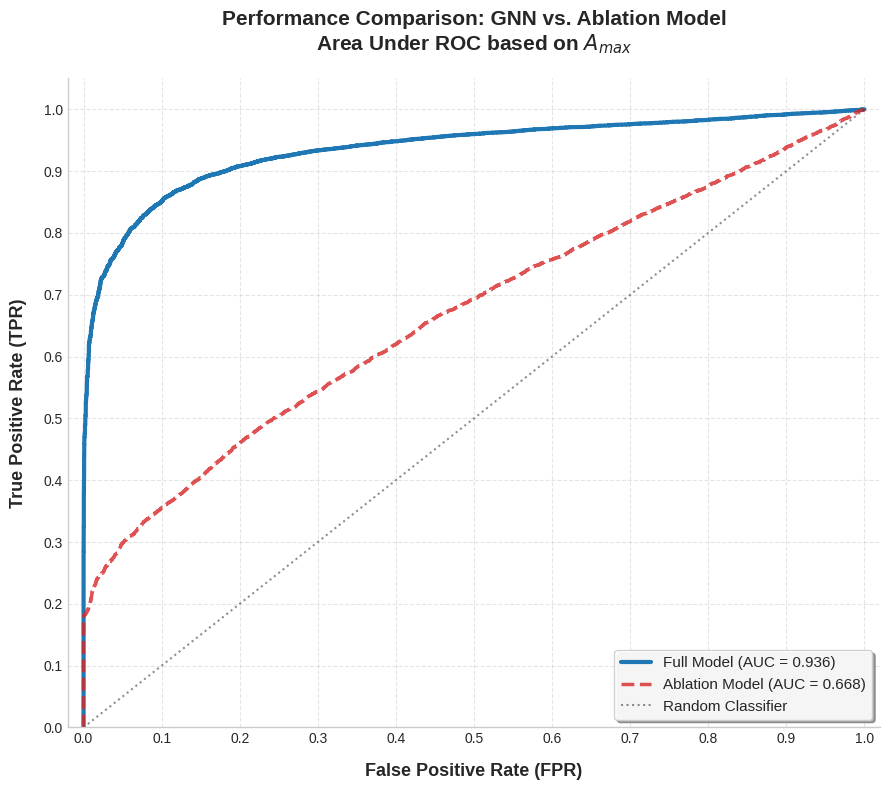

In [ ]:
plot_AUROC_A_model(flatten_concat(tm_motor_test_max, tm_inv_all_max),
                      flatten_concat(a_win_max_motor_test_fm_stack, a_win_max_inv_all_fm_stack),
                      flatten_concat(a_win_max_motor_test_am_stack, a_win_max_inv_all_am_stack))

##

##